In [19]:
import numpy as np
from helpers import *
import matplotlib.pyplot as plt
import tqdm
import pandas as pd

In [2]:
from sklearn.model_selection import KFold

In [3]:
from collections import defaultdict

In [16]:
def mean_squared_error_cv(x, y, model, nfolds=5):
    kf = KFold(n_splits=nfolds, random_state=None, shuffle=False)
    scores = []
    
    for i, (train_index, test_index) in enumerate(kf.split(x)):
        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index] 

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        score = mean_squared_error(y_test, y_pred)
        scores.append(score)
    return np.mean(scores)

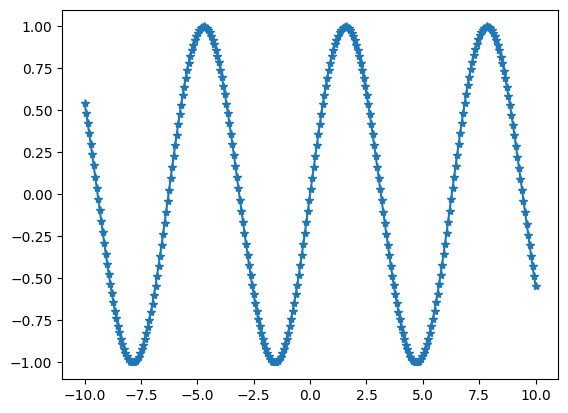

In [17]:
f = lambda x: np.sin(x)

x = np.linspace(-10, 10, 300)
y = f(x)

plt.plot(x, y, "-*")

In [28]:
paramsearch = OptunaHyperparameterTuning(
    KRRWrapper,
    param_grid={
        "bandwidth": dict(type="float", min=1e-9, max=4),
        "reg": dict(type="float", min=1e-12, max=1e-2)
    },
    scoring=mean_squared_error,
    n_trials=100
)

In [29]:
noise = 0.1

In [30]:
# DS 1
y1 = f(x) + noise*np.random.normal(0, 1, len(x))
paramsearch.fit(x, y1)
b1, r1 = paramsearch.best_params.values()

model1 = KRRWrapper(b1, r1)
mean_squared_error_cv(x, y, model1)

np.float64(0.05908333835816983)

In [42]:
# DS 2
y2 = f(2*x) + noise*np.random.normal(0, 1, len(x))
paramsearch.fit(x, y2)
b2, r2 = paramsearch.best_params.values()

model2 = KRRWrapper(b2, r2)
mean_squared_error_cv(x, y, model2)

np.float64(0.3593661870213877)

In [43]:
# Joint
y_joint = np.concatenate([y1, y2])
x_joint = np.concatenate([x, x])

paramsearch.fit(x_joint, y_joint)
b_joint, r_joint = paramsearch.best_params.values()

In [44]:
model_joint = KRRWrapper(b_joint, r_joint)
print(mean_squared_error_cv(x_joint, y_joint, model_joint))

model_joint_1 = KRRWrapper(b_joint, r_joint)
model_joint_1.alpha = model_joint.model.alpha[:len(x)]

model_joint_2 = KRRWrapper(b_joint, r_joint)
model_joint_2.alpha = model_joint.model.alpha[len(x):]

0.5768695916802624


In [45]:
print(mean_squared_error_cv(x, y1, model_joint_1))
print(mean_squared_error_cv(x, y2, model_joint_2))

1.065032276626957
0.8073261162042685


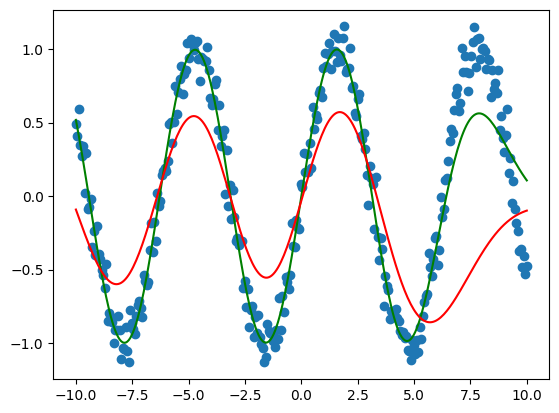

In [46]:
plt.scatter(x, y1)
plt.plot(x, model1.predict(x), c="g")
plt.plot(x, model_joint_1.predict(x), c="r")

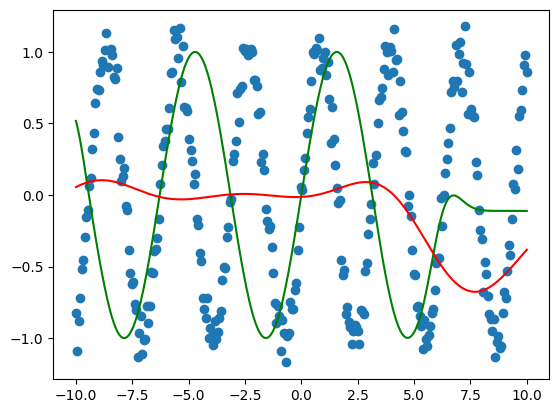

In [47]:
plt.scatter(x, y2)
plt.plot(x, model2.predict(x), c="g")
plt.plot(x, model_joint_2.predict(x), c="r")

In [25]:
1/0

ZeroDivisionError: division by zero

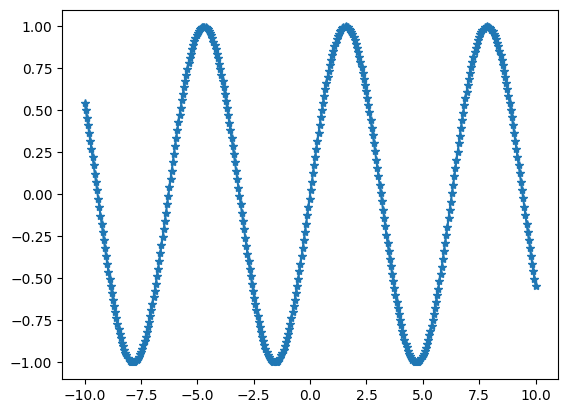

In [41]:
f = lambda x: np.sin(x)
x = np.linspace(-10, 10, 400)

plt.plot(x, f(x), "-*")

In [62]:
frequencies = np.linspace(0.5, 1.5, 50)
N_runs = 100
sigma = 1

In [63]:
paramsearch = OptunaHyperparameterTuning(
    KRRWrapper,
    param_grid={
        "bandwidth": dict(type="float", min=1e-9, max=4),
        "reg": dict(type="float", min=1e-9, max=1e-1)
    },
    scoring=mean_squared_error,
    n_trials=30
)

In [64]:
results = defaultdict(list)

In [65]:
for freq in tqdm.tqdm(frequencies):
    temp_results = defaultdict(list)

    for i in range(N_runs):
        y1 = f(x) 
        y1_data = y1 + np.random.normal(0, sigma, len(y1))

        y2 = f(freq*x) 
        y2_data = y2 + np.random.normal(0, sigma, len(y2))

        # Joint
        y_joint = np.concatenate([y1, y2])
        y_joint_data = np.concatenate([y1_data, y2_data])
        x_joint = np.concatenate([x, x])

        paramsearch.fit(x_joint, y_joint_data)
        b_joint, r_joint = paramsearch.best_params.values()

        model_joint = KRRWrapper(b_joint, r_joint)
        model_joint.fit(x_joint, y_joint_data)
        y_pred = model_joint.predict(x_joint)

        alpha1 = model_joint.model.alpha[:len(x)]
        alpha2 = model_joint.model.alpha[len(x):]
        kernel = model_joint.model.kernels[0]

        ip1 = alpha1.T@kernel(x, x)@alpha1
        ip2 = alpha2.T@kernel(x, x)@alpha2
        ip12 = alpha1.T@kernel(x, x)@alpha2


        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred, y_joint))
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_joint_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

    results["frequency"].append(freq)
    results["experiment"].append("Same Bandwidth")
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

100%|██████████| 50/50 [3:58:09<00:00, 285.79s/it]  


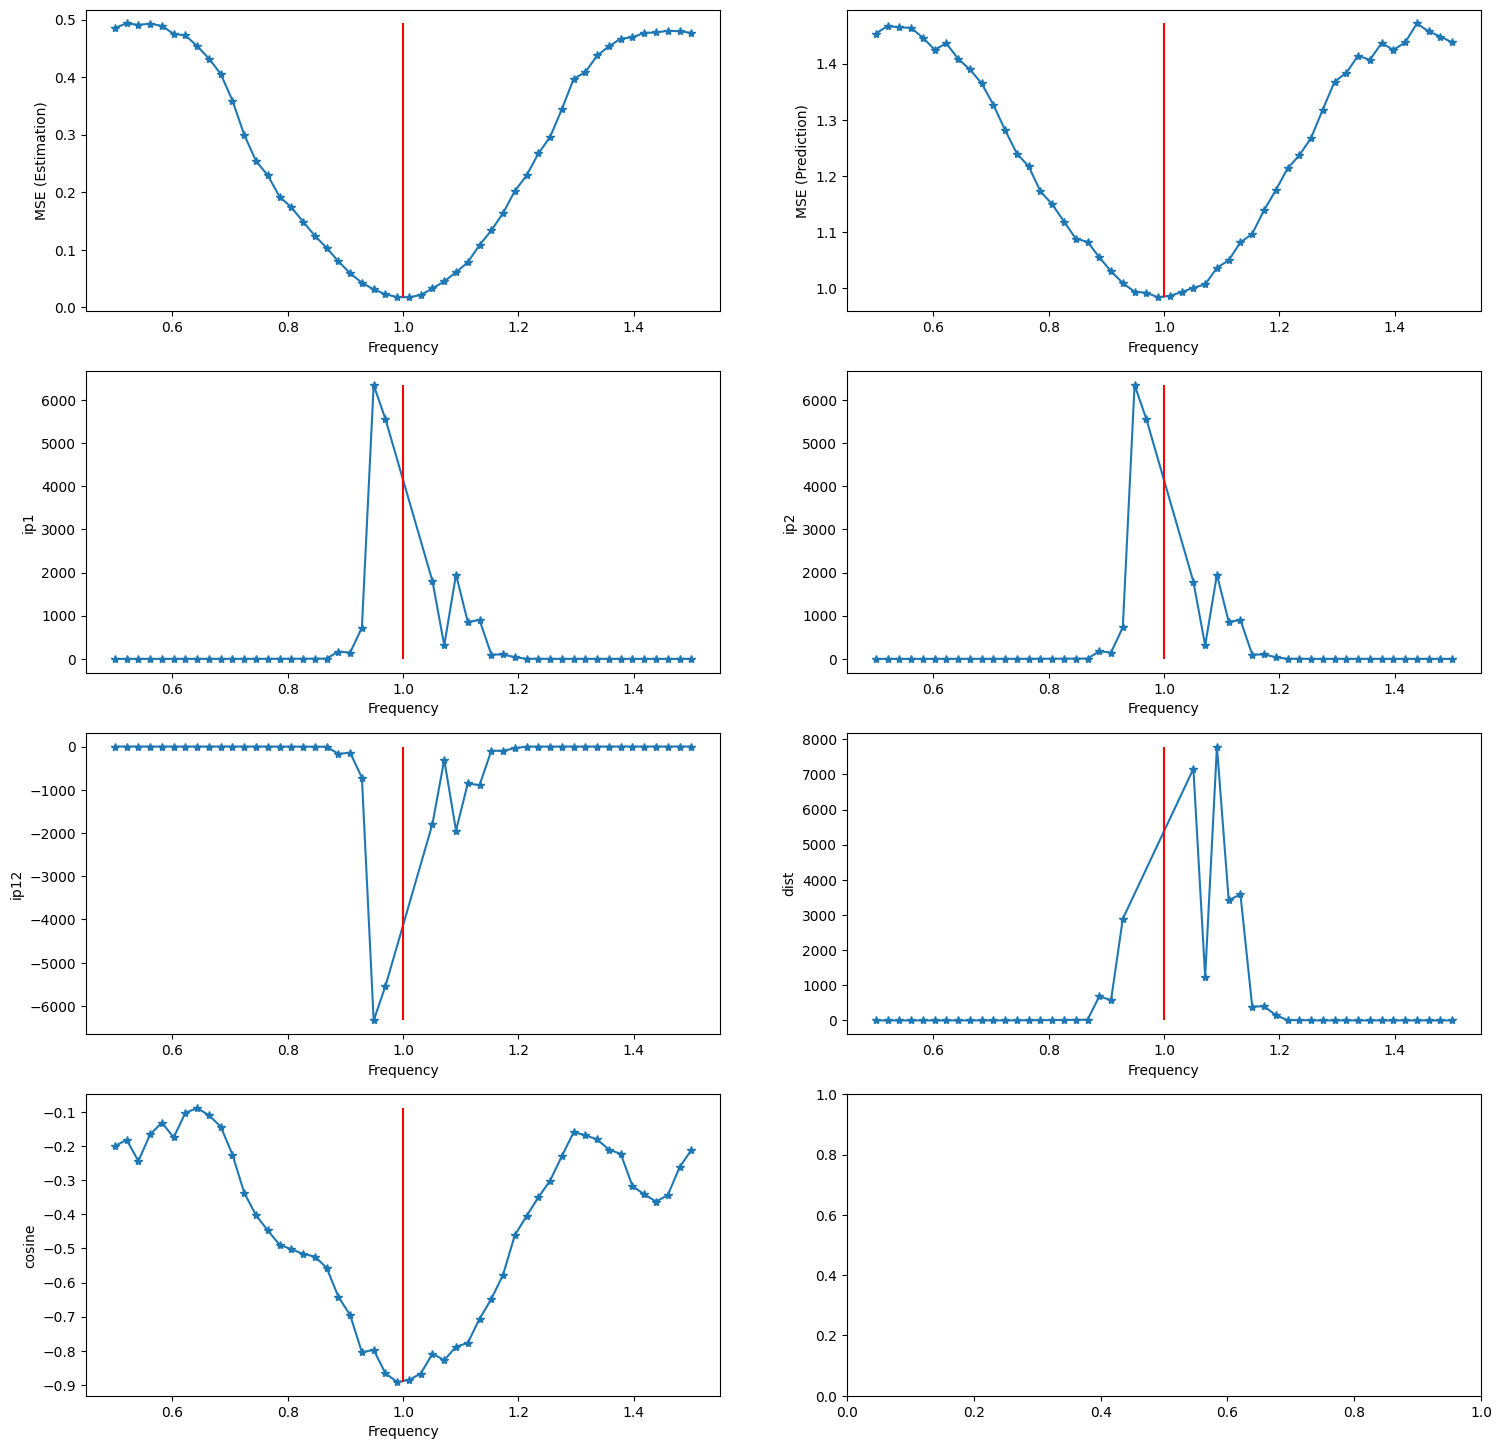

In [72]:
df = pd.DataFrame(results)
df.to_csv("pairwise_test.csv")
# Create figures
cols = [i for i in df.columns if i not in ["frequency", "experiment"]]
fig, axes = plt.subplots(ncols=2, nrows=int(np.ceil(len(cols)/2)), figsize=(18, 18))

axes = list(axes.flat)

for i in range(len(cols)):
    df_sub = df[df[cols[i]].abs() < 10000]
    axes[i].plot(df_sub["frequency"], df_sub[cols[i]], "-*")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel(cols[i])
    axes[i].vlines(1, df_sub[cols[i]].min(), df_sub[cols[i]].max(), color="red")

plt.savefig("pairwise_test.png")